# Fold 4 (test set): Statistical plots by dataset condition

Focus: differences across **SaMi-Trop**, **PTB-XL**, and **CODE-15%** within **fold = 4**.

Columns: `age`, `sex` (normalized to `sex_norm`), `qc_templatematch_bp`.

Note: violin plots are drawn on a capped *per-group* sample for speed (they remain representative for shape comparisons).

In [6]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

sns.set_theme(context="talk", style="whitegrid")
sns.set_palette("colorblind")

# --- Configure metadata path ---
# You can also set an env var: META_PATH=/path/to/metadata.csv
META_PATH = Path(
    os.environ.get(
        "META_PATH",
        "/home/flo178/projects/master-thesis/datasets/physionet2025/processedMaster/metadata.csv",
    )
)

if not META_PATH.is_file():
    raise FileNotFoundError(
        f"Metadata CSV not found: {META_PATH}. "
        "Set META_PATH env var or update META_PATH in this notebook."
    )

df = pd.read_csv(META_PATH, low_memory=False)

required = {"age", "sex", "chagas", "source", "fold"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in metadata: {sorted(missing)}")

# --- Normalize columns ---
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df.loc[df["age"] >= 300, "age"] = 90  # PTB-XL HIPAA mask

def normalize_sex(val):
    if pd.isna(val):
        return "Unknown"
    if isinstance(val, bool):
        return "Male" if val else "Female"
    if isinstance(val, (int, float, np.integer, np.floating)):
        if val == 0:
            return "Male"
        if val == 1:
            return "Female"
        return "Unknown"
    if isinstance(val, str):
        v = val.strip().lower()
        if v.startswith("m"):
            return "Male"
        if v.startswith("f"):
            return "Female"
    return "Unknown"

df["sex_norm"] = df["sex"].apply(normalize_sex)

df["fold"] = pd.to_numeric(df["fold"], errors="coerce").astype("Int64")
df["chagas"] = pd.to_numeric(df["chagas"], errors="coerce")
df = df.dropna(subset=["fold", "chagas", "source"]).copy()
df["chagas"] = df["chagas"].astype(int)

# Canonicalize source names for consistent plotting
df["source_norm"] = df["source"].astype(str).replace(
    {
        "CODE-15": "CODE-15%",
        "Sami-Trop": "SaMi-Trop",
    }
)

fold4 = df[df["fold"] == 4].copy()

sources_focus = ["SaMi-Trop", "PTB-XL", "CODE-15%"]
present_sources = [s for s in sources_focus if s in set(fold4["source_norm"])]
if not present_sources:
    raise ValueError(
        f"No fold=4 rows found for focus sources {sources_focus}. "
        f"Available sources in fold 4: {sorted(fold4['source_norm'].unique().tolist())}"
    )
fold4 = fold4[fold4["source_norm"].isin(present_sources)].copy()

def sample_per_group(
    frame: pd.DataFrame,
    group_cols: list[str],
    *,
    max_n: int = 20000,
    seed: int = 42,
) -> pd.DataFrame:
    if len(frame) <= max_n:
        return frame
    parts = []
    for _, g in frame.groupby(group_cols, dropna=False):
        if len(g) > max_n:
            parts.append(g.sample(n=max_n, random_state=seed))
        else:
            parts.append(g)
    return pd.concat(parts, ignore_index=True)

fold4.head()

,exam_id,age,sex,chagas,source,path,resample_method,qc_zhao2018_bp,qc_templatematch_bp,patient_id,fold,proc_stem,processed_root,sex_norm,source_norm
21,678585,61,Female,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,Cached,Excellent,0.997299,678585,4,678585,/home/flo178/projects/master-thesis/datasets/p...,Female,CODE-15%
22,488114,48,Male,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,Cached,Excellent,0.996018,488114,4,488114,/home/flo178/projects/master-thesis/datasets/p...,Male,CODE-15%
31,2666300,85,Male,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,Cached,Unacceptable,0.897009,2666300,4,2666300,/home/flo178/projects/master-thesis/datasets/p...,Male,CODE-15%
36,125412,51,Female,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,Cached,Excellent,0.997814,125412,4,125412,/home/flo178/projects/master-thesis/datasets/p...,Female,CODE-15%
39,1430471,56,Male,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,Cached,Barely acceptable,0.998207,1430471,4,1430471,/home/flo178/projects/master-thesis/datasets/p...,Male,CODE-15%


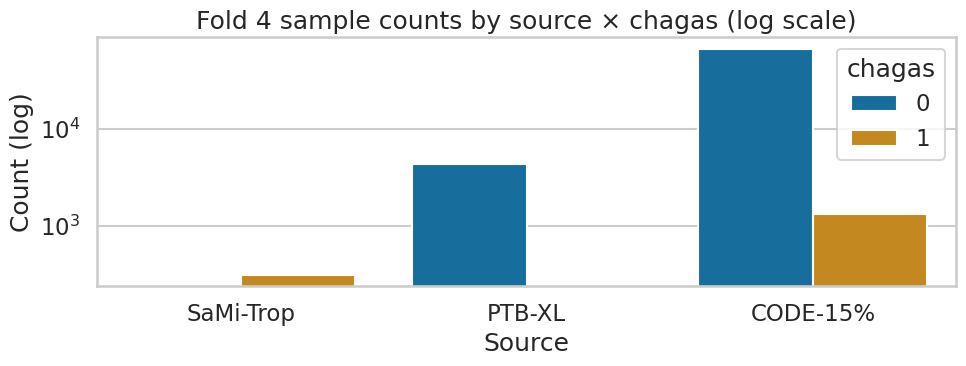

In [7]:
# Fold-4 composition by dataset condition (log scale)
counts = (
    fold4.groupby(["source_norm", "chagas"])  # 0/1
    .size()
    .rename("n")
    .reset_index()
)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.barplot(
    data=counts,
    x="source_norm",
    y="n",
    hue="chagas",
    order=present_sources,
    hue_order=[0, 1],
    ax=ax,
)
ax.set_yscale("log")
ax.set_title("Fold 4 sample counts by source × chagas (log scale)")
ax.set_xlabel("Source")
ax.set_ylabel("Count (log)")
ax.legend(title="chagas")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2536956/1878557804.py:6: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


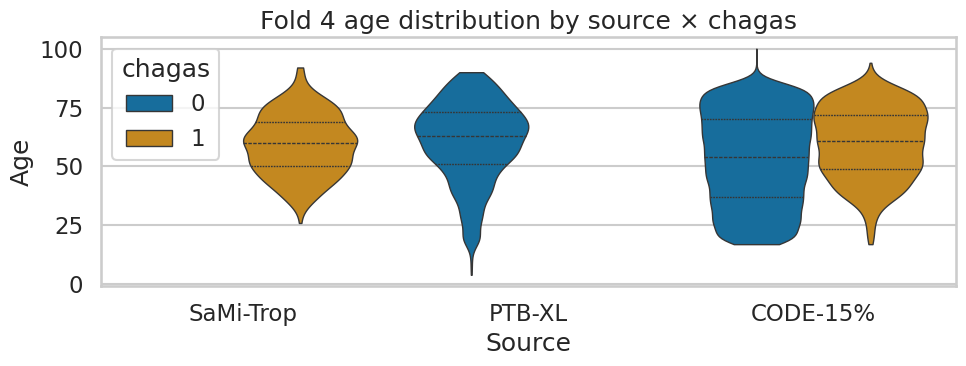

In [8]:
# Age distribution (violin) by dataset condition, split by chagas
age_df = fold4.dropna(subset=["age"]).copy()
age_df = sample_per_group(age_df, ["source_norm", "chagas"], max_n=20000)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.violinplot(
    data=age_df,
    x="source_norm",
    y="age",
    hue="chagas",
    order=present_sources,
    hue_order=[0, 1],
    cut=0,
    inner="quartile",
    scale="width",
    linewidth=1,
    ax=ax,
)
ax.set_title("Fold 4 age distribution by source × chagas")
ax.set_xlabel("Source")
ax.set_ylabel("Age")
ax.legend(title="chagas")
plt.tight_layout()
plt.show()

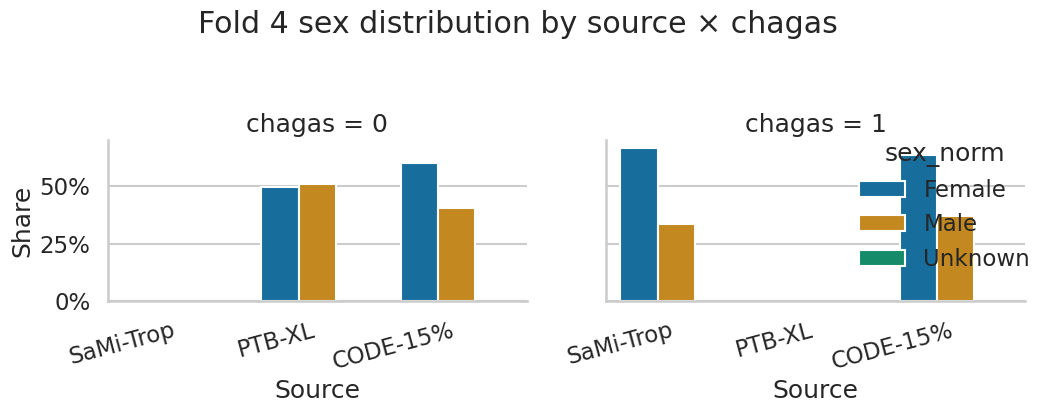

In [9]:
# Sex distribution (percent) by dataset condition, split by chagas
sex_counts = (
    fold4.groupby(["source_norm", "chagas", "sex_norm"]).size().rename("n").reset_index()
)
totals = (
    sex_counts.groupby(["source_norm", "chagas"])["n"].sum().rename("n_total").reset_index()
)
sex_long = sex_counts.merge(totals, on=["source_norm", "chagas"], how="left")
sex_long["frac"] = sex_long["n"] / sex_long["n_total"].clip(lower=1)

g = sns.catplot(
    data=sex_long,
    kind="bar",
    x="source_norm",
    y="frac",
    hue="sex_norm",
    col="chagas",
    order=present_sources,
    hue_order=["Female", "Male", "Unknown"],
    col_order=[0, 1],
    height=4,
    aspect=1.1,
    sharey=True,
)
g.set_axis_labels("Source", "Share")
for ax in g.axes.flatten():
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    for label in ax.get_xticklabels():
        label.set_rotation(15)
        label.set_horizontalalignment("right")
g.set_titles("chagas = {col_name}")
g.fig.suptitle("Fold 4 sex distribution by source × chagas", y=1.05)
plt.tight_layout()
plt.show()

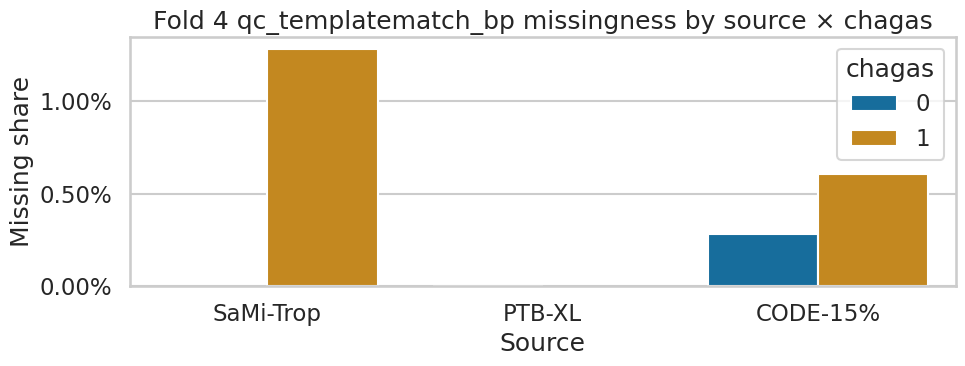

/tmp/ipykernel_2536956/2744081027.py:40: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


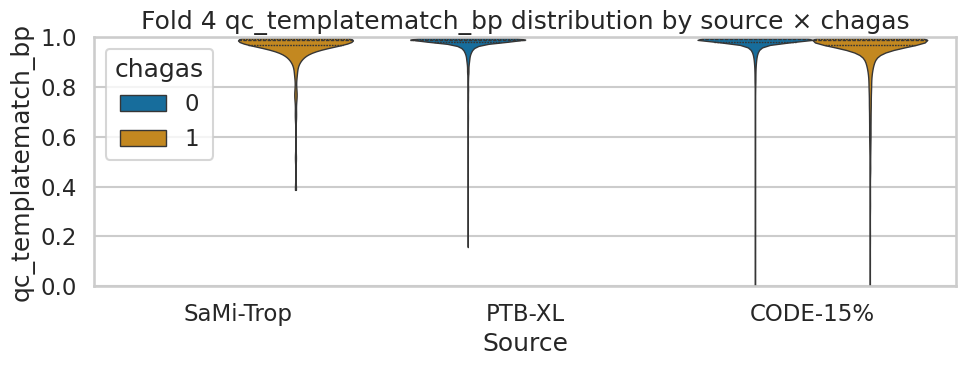

In [10]:
# QC templatematch distribution (violin) by dataset condition, split by chagas
qc = fold4[["source_norm", "chagas", "qc_templatematch_bp"]].copy() if "qc_templatematch_bp" in fold4.columns else None
if qc is None:
    raise ValueError("Missing column qc_templatematch_bp in metadata")

qc["qc_templatematch_bp"] = pd.to_numeric(qc["qc_templatematch_bp"], errors="coerce")

# Missingness (percent)
miss = (
    qc.assign(is_missing=qc["qc_templatematch_bp"].isna())
    .groupby(["source_norm", "chagas"])["is_missing"]
    .mean()
    .rename("missing_frac")
    .reset_index()
)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.barplot(
    data=miss,
    x="source_norm",
    y="missing_frac",
    hue="chagas",
    order=present_sources,
    hue_order=[0, 1],
    ax=ax,
)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Fold 4 qc_templatematch_bp missingness by source × chagas")
ax.set_xlabel("Source")
ax.set_ylabel("Missing share")
ax.legend(title="chagas")
plt.tight_layout()
plt.show()

qc_df = qc.dropna(subset=["qc_templatematch_bp"]).copy()
qc_df["qc_templatematch_bp"] = qc_df["qc_templatematch_bp"].clip(0, 1)
qc_df = sample_per_group(qc_df, ["source_norm", "chagas"], max_n=20000)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.violinplot(
    data=qc_df,
    x="source_norm",
    y="qc_templatematch_bp",
    hue="chagas",
    order=present_sources,
    hue_order=[0, 1],
    cut=0,
    inner="quartile",
    scale="width",
    linewidth=1,
    ax=ax,
)
ax.set_ylim(0, 1)
ax.set_title("Fold 4 qc_templatematch_bp distribution by source × chagas")
ax.set_xlabel("Source")
ax.set_ylabel("qc_templatematch_bp")
ax.legend(title="chagas")
plt.tight_layout()
plt.show()

## QC correlation: `qc_templatematch_bp` vs `qc_zhao2018_bp`

`qc_zhao2018_bp` is a categorical NeuroKit2 quality label. To quantify association with the continuous templatematch score, we compute:
- **η² (eta-squared)**: fraction of templatematch variance explained by the Zhao category.
- **Spearman (ordinalized)**: we order categories by median templatematch (low→high) and compute Spearman correlation with that induced ordering.

,qc_zhao2018_bp,source_norm,chagas,n
4,Excellent,CODE-15%,0,48189
0,Barely acceptable,CODE-15%,0,16464
6,Excellent,PTB-XL,0,2852
9,Unacceptable,CODE-15%,0,2618
2,Barely acceptable,PTB-XL,0,1260
5,Excellent,CODE-15%,1,764
1,Barely acceptable,CODE-15%,1,429
11,Unacceptable,PTB-XL,0,220
7,Excellent,SaMi-Trop,1,152
3,Barely acceptable,SaMi-Trop,1,131


Overall (fold 4):
  eta^2(qc_zhao2018_bp -> templatematch) = 0.05846696021101447
  spearman(ordinalized qc_zhao2018_bp, templatematch) = 0.20003046954929937


,source,n,zhao_categories,eta2,spearman_ordinalized
0,CODE-15%,68394,3,0.059877,0.195837
1,PTB-XL,4332,3,0.058928,0.259856
2,SaMi-Trop,308,3,0.020933,0.125984


/tmp/ipykernel_2536956/1759875687.py:69: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


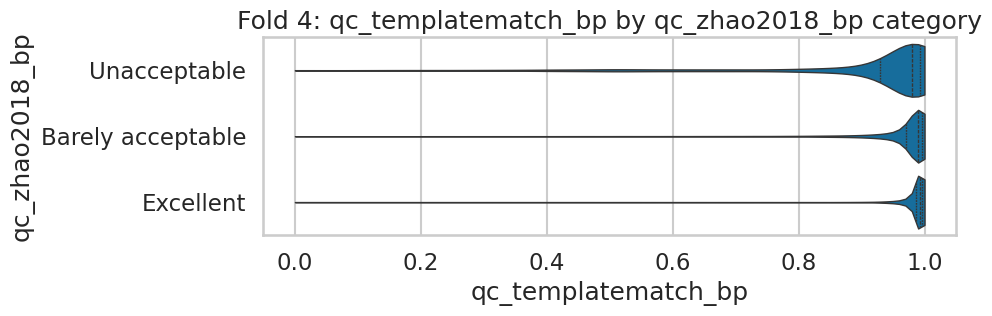

In [11]:
if "qc_zhao2018_bp" not in fold4.columns:
    raise ValueError("Missing column qc_zhao2018_bp in metadata")

qc2 = fold4[["source_norm", "chagas", "qc_zhao2018_bp", "qc_templatematch_bp"]].copy()
qc2["qc_templatematch_bp"] = pd.to_numeric(qc2["qc_templatematch_bp"], errors="coerce").clip(0, 1)
qc2["qc_zhao2018_bp"] = qc2["qc_zhao2018_bp"].astype("string").fillna("Missing")

# Quick counts per category
display(
    qc2.groupby(["qc_zhao2018_bp", "source_norm", "chagas"]).size().rename("n").reset_index().sort_values("n", ascending=False).head(30)
)

# Keep only rows with numeric templatematch
qc2n = qc2.dropna(subset=["qc_templatematch_bp"]).copy()

def eta_squared(y: pd.Series, groups: pd.Series) -> float:
    y = pd.to_numeric(y, errors="coerce")
    ok = (~y.isna()) & (~groups.isna())
    y = y[ok]
    groups = groups[ok]
    if len(y) < 2:
        return float("nan")
    overall_mean = float(y.mean())
    ss_total = float(((y - overall_mean) ** 2).sum())
    if ss_total == 0.0:
        return float("nan")

    by = pd.DataFrame({"y": y, "g": groups}).groupby("g")["y"]
    means = by.mean()
    ns = by.size()
    ss_between = float((ns * (means - overall_mean) ** 2).sum())
    return ss_between / ss_total

def spearman_ordinalized(frame: pd.DataFrame) -> float:
    if frame["qc_zhao2018_bp"].nunique(dropna=True) < 2:
        return float("nan")
    med = frame.groupby("qc_zhao2018_bp")["qc_templatematch_bp"].median().sort_values()
    mapping = {cat: i for i, cat in enumerate(med.index.tolist())}
    z_ord = frame["qc_zhao2018_bp"].map(mapping)
    return float(frame["qc_templatematch_bp"].corr(z_ord, method="spearman"))

# Overall association (fold 4, focus sources)
overall_eta2 = eta_squared(qc2n["qc_templatematch_bp"], qc2n["qc_zhao2018_bp"])
overall_spear = spearman_ordinalized(qc2n)
print("Overall (fold 4):")
print("  eta^2(qc_zhao2018_bp -> templatematch) =", overall_eta2)
print("  spearman(ordinalized qc_zhao2018_bp, templatematch) =", overall_spear)

# Per-source association
rows = []
for src, sub in qc2n.groupby("source_norm"):
    rows.append(
        {
            "source": src,
            "n": len(sub),
            "zhao_categories": int(sub["qc_zhao2018_bp"].nunique()),
            "eta2": eta_squared(sub["qc_templatematch_bp"], sub["qc_zhao2018_bp"]),
            "spearman_ordinalized": spearman_ordinalized(sub),
        }
    )
display(pd.DataFrame(rows).sort_values(["source"]))

# Plot: templatematch by Zhao category (category order induced by median templatematch)
med = qc2n.groupby("qc_zhao2018_bp")["qc_templatematch_bp"].median().sort_values()
zhao_order = med.index.tolist()
plot_df = sample_per_group(qc2n, ["qc_zhao2018_bp"], max_n=20000)

fig, ax = plt.subplots(1, 1, figsize=(10, max(3.5, 0.5 * len(zhao_order))))
sns.violinplot(
    data=plot_df,
    y="qc_zhao2018_bp",
    x="qc_templatematch_bp",
    order=zhao_order,
    cut=0,
    inner="quartile",
    scale="width",
    linewidth=1,
    ax=ax,
)
ax.set_title("Fold 4: qc_templatematch_bp by qc_zhao2018_bp category")
ax.set_xlabel("qc_templatematch_bp")
ax.set_ylabel("qc_zhao2018_bp")
plt.tight_layout()
plt.show()

## ECG delineation (NeuroKit2) for a selected fold-4 sample

This cell loads one processed ECG tensor (``.pt``) for a chosen ``exam_id`` and runs ``nk.ecg_delineate(method="dwt")``.
It displays:
- the NeuroKit2 delineation plot (``show=True``)
- a tidy table of onset/offset indices per detected beat for downstream aggregation.


In [ ]:
import torch
import neurokit2 as nk
from IPython.display import display
import os
from pathlib import Path

# --- Choose a sample (edit these) ---
SAMPLING_RATE = 400  # Hz
LEAD_INDEX = 1       # 0..11 (same convention as in the rest of the project)
CASE_SOURCE = 'CODE-15%'  # 'SaMi-Trop' | 'PTB-XL' | 'CODE-15%'
CASE_CHAGAS = 1           # 0/1
EXAM_ID = None            # optionally set a specific exam_id (string); otherwise auto-pick one

sub = fold4[(fold4['source_norm'] == CASE_SOURCE) & (fold4['chagas'] == int(CASE_CHAGAS))].copy()
if sub.empty:
    raise ValueError(f'No fold-4 rows for source={CASE_SOURCE!r}, chagas={CASE_CHAGAS}')

if EXAM_ID is None:
    row = sub.iloc[0]
else:
    row = sub[sub['exam_id'].astype(str).eq(str(EXAM_ID))].iloc[0]

exam_id = str(row['exam_id'])

# Default tensor dir: <processed_root>/<proc_stem> (override via env var DATA_DIR if needed)
default_data_dir = Path(str(row.get('processed_root', ''))).expanduser() / str(row.get('proc_stem', '')).strip()
DATA_DIR = Path(os.environ.get('DATA_DIR', str(default_data_dir))).expanduser()
pt_path = DATA_DIR / f'{exam_id}.pt'
if not pt_path.is_file():
    raise FileNotFoundError(f'Missing tensor file: {pt_path} (set env var DATA_DIR to override)')

ecg = torch.load(pt_path, map_location='cpu')
if isinstance(ecg, dict):
    # Some pipelines store dict-like samples; try common keys.
    for k in ('ecg', 'signal', 'x'):
        if k in ecg:
            ecg = ecg[k]
            break

if hasattr(ecg, 'ndim') and ecg.ndim == 3:
    # [1,C,T] -> [C,T]
    ecg = ecg[0]

ecg_np = ecg.detach().cpu().numpy() if hasattr(ecg, 'detach') else ecg
shape = getattr(ecg_np, 'shape', None)
if shape is None or len(shape) != 2 or shape[0] != 12:
    raise ValueError(f'Expected ECG shape [12,T], got {shape} from {pt_path}')

ecg_signal = ecg_np[int(LEAD_INDEX)].astype('float64', copy=False)

# --- NeuroKit2: clean -> R-peaks -> delineation ---
ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=SAMPLING_RATE, method='neurokit')
signals_peaks, info_peaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=SAMPLING_RATE)
rpeaks = info_peaks['ECG_R_Peaks']

signal_dwt, waves_dwt = nk.ecg_delineate(
    ecg_cleaned,
    rpeaks,
    sampling_rate=SAMPLING_RATE,
    method='dwt',
    show=True,
    show_type='all',
)

# Convert returned wave indices into a rectangular table (columns may have different lengths)
waves_df = pd.DataFrame({k: pd.Series(v) for k, v in waves_dwt.items()}).sort_index(axis=1)

display(pd.DataFrame([{
    'exam_id': exam_id,
    'source': row.get('source_norm', row.get('source', '')),
    'chagas': int(row.get('chagas', -1)),
    'lead_index': int(LEAD_INDEX),
    'qc_zhao2018_bp': row.get('qc_zhao2018_bp', None),
    'qc_templatematch_bp': row.get('qc_templatematch_bp', None),
    'tensor_path': str(pt_path),
    'n_rpeaks': int(len(rpeaks)),
}]))

display(waves_df.head(20))

# Tip: rpeaks are in `rpeaks` (sample indices); delineation indices live in `waves_df` columns.
